# EDA: CMAPSS FD001
Turbofan degradation data. One operating condition, one fault mode.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
cols = (
    ['engine_id', 'cycle']
    + [f'op_setting_{i}' for i in range(1, 4)]
    + [f'sensor_{i}' for i in range(1, 22)]
)

# space-separated, no header, trailing whitespace requires sep='\s+'
df = pd.read_csv(
    '../data/train_FD001.txt',
    sep='\s+',
    header=None,
    names=cols,
    engine='python'
)

In [3]:
print('shape:', df.shape)
print()
print(df.dtypes)
print()
df.head()

shape: (20631, 26)

engine_id         int64
cycle             int64
op_setting_1    float64
op_setting_2    float64
op_setting_3    float64
sensor_1        float64
sensor_2        float64
sensor_3        float64
sensor_4        float64
sensor_5        float64
sensor_6        float64
sensor_7        float64
sensor_8        float64
sensor_9        float64
sensor_10       float64
sensor_11       float64
sensor_12       float64
sensor_13       float64
sensor_14       float64
sensor_15       float64
sensor_16       float64
sensor_17         int64
sensor_18         int64
sensor_19       float64
sensor_20       float64
sensor_21       float64
dtype: object



,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
print('unique engines:', df['engine_id'].nunique())
print('cycle range:  ', df['cycle'].min(), '-', df['cycle'].max())

unique engines: 100
cycle range:   1 - 362


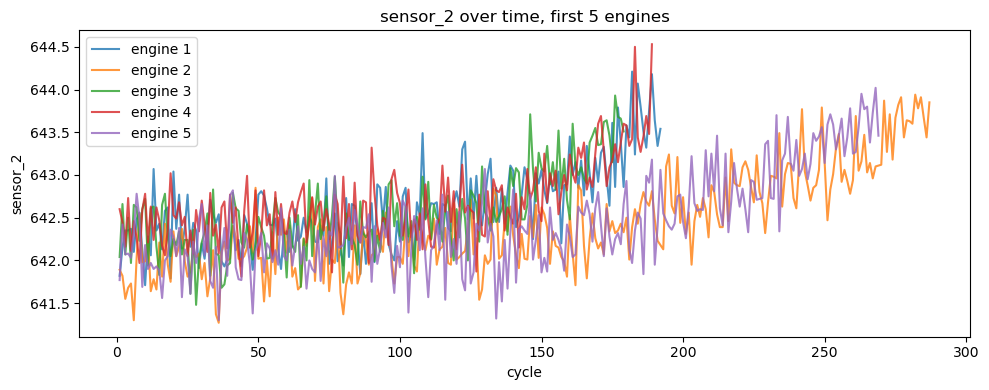

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))

# first 5 engines give a readable spread without overplotting
for eid in sorted(df['engine_id'].unique())[:5]:
    eng = df[df['engine_id'] == eid]
    ax.plot(eng['cycle'], eng['sensor_2'], label=f'engine {eid}', alpha=0.8)

ax.set_xlabel('cycle')
ax.set_ylabel('sensor_2')
ax.set_title('sensor_2 over time, first 5 engines')
ax.legend()
plt.tight_layout()
plt.show()